# Video import

In [ ]:
import colab

In [27]:
crop_range = {"top": 870, "bottom": 1000, "left": 120, "right": 1800}
video_path = './videos/Squid_game.mp4'
sample_index = 1500

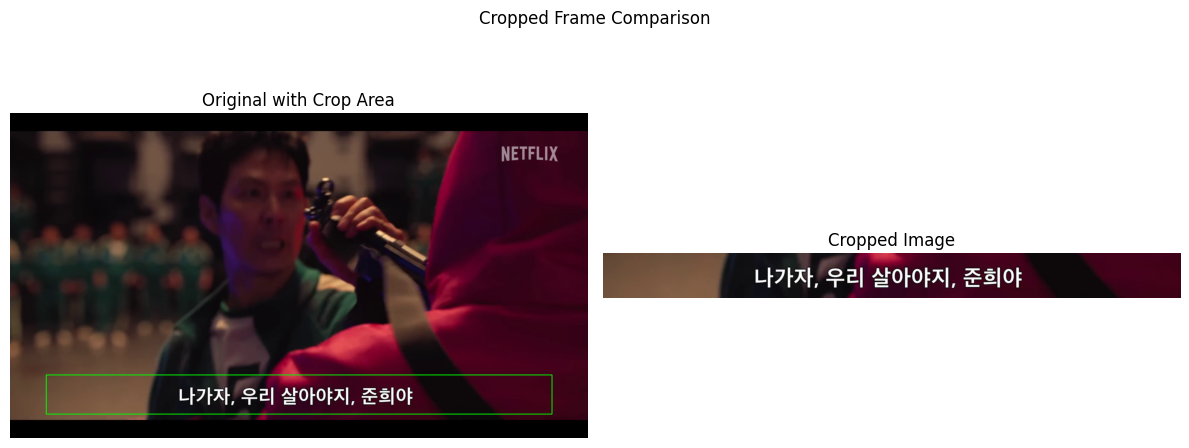

In [57]:
import cv2
import matplotlib.pyplot as plt

def load_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    return frames

def crop_image(image, crop_range):
    top = crop_range["top"]
    bottom = crop_range["bottom"]
    left = crop_range["left"]
    right = crop_range["right"]
    
    return image[top:bottom, left:right]

def crop_video(frames, crop_range):
    top = crop_range["top"]
    bottom = crop_range["bottom"]
    left = crop_range["left"]
    right = crop_range["right"]
    
    cropped_frames = []
    for frame in frames:
        if frame is not None:
            cropped_frame = frame[top:bottom, left:right]
            cropped_frames.append(cropped_frame)
    return cropped_frames

def display_frame(frame, title="Frame"):
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

def display_cropped_frame(frame, crop_range, title="Cropped Frame Comparison"):
    plt.figure(figsize=(12, 5)) # 전체 그림 크기 유지 또는 조절
    plt.suptitle(title) # 전체 그림의 제목

    # 1. 원본 이미지에 크롭 영역 표시
    original_frame_with_crop_rect = frame.copy()
    cv2.rectangle(original_frame_with_crop_rect, 
                    (crop_range["left"], crop_range["top"]), 
                    (crop_range["right"], crop_range["bottom"]), 
                    (0, 255, 0), 2) # 초록색 사각형
    plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째
    plt.imshow(cv2.cvtColor(original_frame_with_crop_rect, cv2.COLOR_BGR2RGB))
    plt.title("Original with Crop Area")
    plt.axis('off')

    # 2. 실제 크롭된 이미지 표시
    cropped_img = crop_image(frame, crop_range) # crop_image 함수 사용
    plt.subplot(1, 2, 2) # 1행 2열 중 두 번째
    plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
    plt.title("Cropped Image")
    plt.axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # suptitle과의 간격 조절
    plt.show()

frames = load_video(video_path)
cropped_images = crop_video(frames, crop_range)
image_shape = frames[sample_index].shape
sample_original_image = frames[sample_index]
sample_cropped_image = cropped_images[sample_index]
display_cropped_frame(sample_original_image, crop_range)

# 자막 인식 1: 타겟 픽셀로 타겟 color 지정 > 픽셀 추출

각 프레임에 대해 타겟 color와 똑같으면 픽셀 추출

- images_highlighting_pixel: 프레임별로 detect한 픽셀 모음

In [29]:
target_pixel = (65, 945)
pixel_highlighting_tolerances = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

Target Color (RGB): [255, 255, 255]


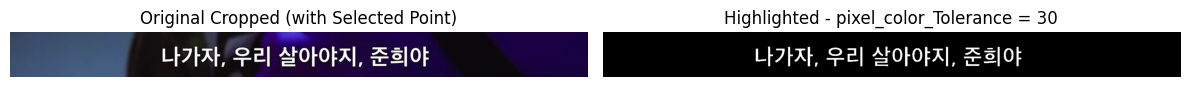

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def get_target_color(cropped_image, target_pixel):
    y, x = target_pixel
    target_color = cropped_image[y, x].astype(int)
    print(f"Target Pixel: {target_pixel}, Color (RGB): {target_color}")

    # 시각화: 선택한 픽셀 위치에 점 표시
    plt.figure(figsize=(5, 5))
    plt.imshow(cropped_image)
    plt.scatter([x], [y], edgecolors='red', facecolors='none', s=30, marker='o', label='Target Pixel')
    plt.title("Cropped Image with Target Pixel")
    plt.legend()
    plt.axis('off')
    plt.show()

    return target_color

def highlight_subtitle_area(cropped_image, target_color, pixel_color_tolerance):
    lower = np.array([max(0, c - pixel_color_tolerance) for c in target_color])
    upper = np.array([min(255, c + pixel_color_tolerance) for c in target_color])

    cropped_bgr = cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR)
    lower_bgr = np.array([lower[2], lower[1], lower[0]])
    upper_bgr = np.array([upper[2], upper[1], upper[0]])
    mask = cv2.inRange(cropped_bgr, lower_bgr, upper_bgr)

    highlighted_image = np.full_like(cropped_image, 0)
    highlighted_image[mask == 255] = [255, 255, 255]

    highlight_result = {
        "cropped_image": cropped_image.copy(),
        "highlighted_image": highlighted_image.copy(),
        "pixel_color_tolerance": pixel_color_tolerance,
        "mask": mask.copy(),
        "white_pixel_count": np.sum(mask == 255),
    }
    return highlight_result

def highlight_subtitle_area_with_multi_tolerances(cropped_image, target_color, tolerances):
    results = []
    for tolerance in tolerances:
        result = highlight_subtitle_area(cropped_image, target_color, tolerance)
        results.append(result)
    return results

def visualize_highlight_result(image, target_color, highlighted_image_result):
    print(f"Target Color (RGB): {target_color}")

    # 원본 크롭 이미지 + 점 표시
    plt.figure(figsize=(12, 5)) # figsize 조절 가능
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Cropped (with Selected Point)")
    plt.axis('off')
    # plt.legend(loc='upper right') # 원본 이미지에는 특별한 legend가 없을 수 있으므로 주석 처리 또는 수정
    
    # 단일 하이라이트된 이미지 시각화
    plt.subplot(1, 2, 2)
    plt.imshow(highlighted_image_result["highlighted_image"])
    plt.title(f"Highlighted - pixel_color_Tolerance = {highlighted_image_result['pixel_color_tolerance']}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# target_color = get_target_color(cropped_images[0], target_pixel)
target_color = [255, 255, 255]

sample_highlight_result = highlight_subtitle_area(sample_cropped_image, target_color, pixel_color_tolerance=30)
visualize_highlight_result(sample_cropped_image, target_color, sample_highlight_result)

highlight_results = highlight_subtitle_area_with_multi_tolerances(sample_cropped_image, target_color, pixel_highlighting_tolerances)

# Bounding Box 추출

- target_color
- images_highlighting_pixel: image별로 detect한 픽셀 모음
- all_boxes_per_image: image별로 모든 박스 모음

In [31]:
psm_modes = {
    "psm6": '--oem 3 --psm 6 -l kor+eng',
    "psm8": '--oem 3 --psm 8 -l kor+eng',
    "psm10": '--oem 3 --psm 10 -l kor+eng'
}
conf_thresholds = [0, 10, 50]

총 9개의 박스가 발견되었습니다.


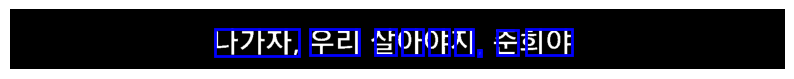

총 722개의 박스가 발견되었습니다.
총 722개의 박스가 발견되었습니다.


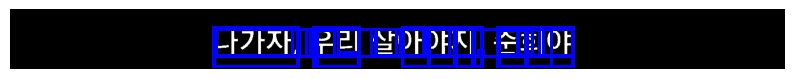

In [32]:
import cv2
import pytesseract
from pytesseract import Output
import matplotlib.pyplot as plt
import numpy as np

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

def find_boundingbox_from_highlighted_image(highlighted_image, tolerance, psm_mode, conf_threshold):

    gray = cv2.cvtColor(highlighted_image, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0.01)
    _, binary = cv2.threshold(blurred, 10, 255, cv2.THRESH_BINARY)
    dilated = cv2.dilate(binary, np.ones((2, 2), np.uint8), iterations=1)

    image_height, image_width = dilated.shape

    ocr_result = pytesseract.image_to_data(
        dilated, output_type=Output.DICT, config=psm_mode
    )
    n_boxes = len(ocr_result['level'])
    boxes = []

    for i in range(n_boxes):
        text = ocr_result['text'][i].strip()
        conf = int(ocr_result['conf'][i])
        x = ocr_result['left'][i]
        y = ocr_result['top'][i]
        w = ocr_result['width'][i]
        h = ocr_result['height'][i]

        if (conf > conf_threshold and text and
            x > 0 and y > 0 and x + w < image_width and y + h < image_height):

            boxes.append({
                "tolerance": tolerance,
                "psm_mode": psm_mode,
                "conf_threshold": conf_threshold,
                "x": x,
                "y": y,
                "w": w,
                "h": h,
                "conf": conf,
                "text": text
            })
    return boxes

def find_boundingbox_from_highlighted_results(highlight_results, psm_modes, conf_thresholds):
    all_boxes = []
    for result in highlight_results:
        highlighted_image = result['highlighted_image']
        pixel_color_tolerance = result['pixel_color_tolerance']
        
        for psm_mode in psm_modes:
            for conf_threshold in conf_thresholds:
                boxes = find_boundingbox_from_highlighted_image(
                    highlighted_image, pixel_color_tolerance, psm_modes[psm_mode], conf_threshold
                )
                if boxes:
                    all_boxes.extend(boxes)
    return all_boxes

def visualize_boxes(image, list_of_boxes):
    print(f"총 {len(list_of_boxes)}개의 박스가 발견되었습니다.")
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    ax = plt.gca()

    for box_info in list_of_boxes: # 리스트의 각 박스 정보에 대해 반복
        x = box_info['x']
        y = box_info['y']
        w = box_info['w']
        h = box_info['h']
        text = box_info.get('text', '') # text 키가 없을 경우 빈 문자열
        conf = box_info.get('conf', -1) # conf 키가 없을 경우 -1

        rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor='blue', linewidth=2)
        ax.add_patch(rect)

    plt.axis('off')
    plt.show()

boxes = find_boundingbox_from_highlighted_image(sample_highlight_result['highlighted_image'], sample_highlight_result['pixel_color_tolerance'], '--oem 3 --psm 6 -l kor+eng', 10)
visualize_boxes(sample_highlight_result['highlighted_image'], boxes)
all_boxes = find_boundingbox_from_highlighted_results(highlight_results, psm_modes, conf_thresholds)
print(f"총 {len(all_boxes)}개의 박스가 발견되었습니다.")
visualize_boxes(sample_highlight_result['highlighted_image'], all_boxes)

# Bounding Box 전처리

Bounding box의 경계가 자막에 맞닿도록 처리

총 722개의 박스가 발견되었습니다.


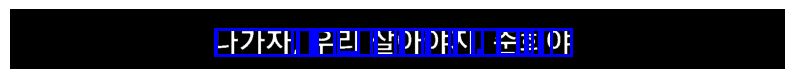

In [33]:
# 색상 유사도 검사 함수
def color_similar(pixel, target_color, tolerance=30):
    pixel = np.array(pixel)
    target_color = np.array(target_color)
    return np.all(np.abs(pixel.astype(int) - target_color.astype(int)) <= tolerance)

def box_trimming(image, box, target_color, box_trimming_tolerance=30):
    x0, y0, w, h = box["x"], box["y"], box["w"], box["h"]
    x_min, y_min, x_max, y_max = x0, y0, x0 + w, y0 + h

    # 이미지 경계에 닿은 박스는 제외
    if x_min == 0 or y_min == 0 or x_max == image.shape[1] or y_max == image.shape[0]:
        return None

    # 위쪽 줄이기
    for yy in range(y_min, y_max):
        line = image[yy, x_min:x_max]
        if np.any([color_similar(px, target_color, box_trimming_tolerance) for px in line]):
            y_min = yy
            break

    # 아래쪽 줄이기
    for yy in range(y_max-1, y_min-1, -1):
        line = image[yy, x_min:x_max]
        if np.any([color_similar(px, target_color, box_trimming_tolerance) for px in line]):
            y_max = yy + 1
            break

    # 왼쪽 줄이기
    for xx in range(x_min, x_max):
        col = image[y_min:y_max, xx]
        if np.any([color_similar(px, target_color, box_trimming_tolerance) for px in col]):
            x_min = xx
            break

    # 오른쪽 줄이기
    for xx in range(x_max-1, x_min-1, -1):
        col = image[y_min:y_max, xx]
        if np.any([color_similar(px, target_color, box_trimming_tolerance) for px in col]):
            x_max = xx + 1
            break

    # 최소 크기 보장
    if x_max > x_min and y_max > y_min:
        trimmed_box = box.copy()
        trimmed_box["x"] = x_min
        trimmed_box["y"] = y_min
        trimmed_box["w"] = x_max - x_min
        trimmed_box["h"] = y_max - y_min
    
    return trimmed_box

def boxes_trimming(image, all_boxes, target_color, box_trimming_tolerance=30):
    trimmed_boxes = []
    for box in all_boxes:
        trimmed_box = box_trimming(image, box, target_color, box_trimming_tolerance)
        if trimmed_box is not None:
            trimmed_boxes.append(trimmed_box)
    return trimmed_boxes

trimmed_boxes = boxes_trimming(sample_highlight_result['highlighted_image'], all_boxes, target_color, box_trimming_tolerance=30)
visualize_boxes(sample_highlight_result['highlighted_image'], trimmed_boxes)

# Y축 길이에 맞춰 histogram 그리기

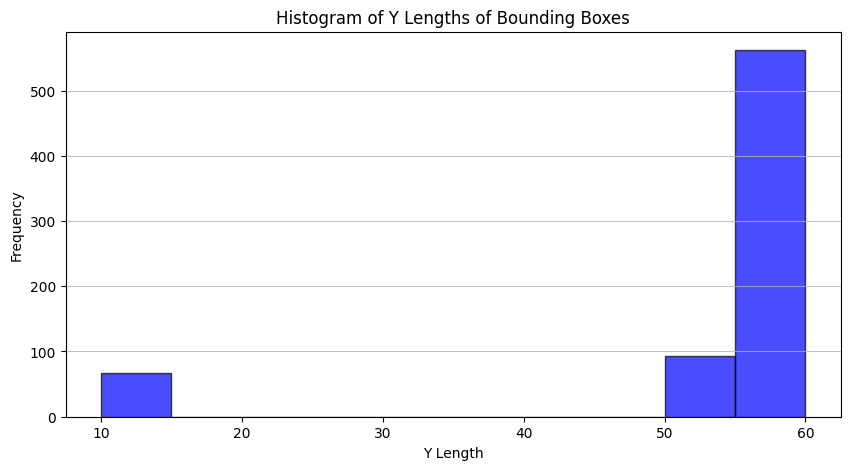

최빈 y 길이 범위: (np.int64(55), np.int64(60)), 개수: 562
총 562개의 박스가 발견되었습니다.


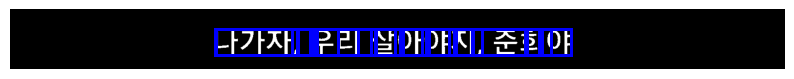

In [34]:
def histogram_ylength(boxes):
    y_lengths = [box['h'] for box in boxes]
    bin_width = 5
    min_val = np.min(y_lengths)
    max_val = np.max(y_lengths)
    bins = np.arange(min_val, max_val + bin_width, bin_width)

    plt.figure(figsize=(10, 5))
    plt.hist(y_lengths, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    plt.title('Histogram of Y Lengths of Bounding Boxes')
    plt.xlabel('Y Length')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

def find_ylength_mode_boxes(boxes):
    y_lengths = [box['h'] for box in boxes]
    bin_width = 5
    min_val = np.min(y_lengths)
    max_val = np.max(y_lengths)
    bins = np.arange(min_val, max_val + bin_width, bin_width)
    
    # 최빈 bin 찾기
    hist, bin_edges = np.histogram(y_lengths, bins=bins)
    mode_index = np.argmax(hist)

    # 최빈 bin에 속하는 box만 추출
    mode_bin = (bin_edges[mode_index], bin_edges[mode_index + 1])
    mode_boxes = [box for box in boxes if mode_bin[0] <= box['h'] < mode_bin[1]]
    print(f"최빈 y 길이 범위: {mode_bin}, 개수: {len(mode_boxes)}")
    return mode_boxes

histogram_ylength(trimmed_boxes)
mode_boxes = find_ylength_mode_boxes(trimmed_boxes)

visualize_boxes(sample_highlight_result['highlighted_image'], mode_boxes)

# 최종 자막 pixel 추출

총 1개의 박스가 발견되었습니다.


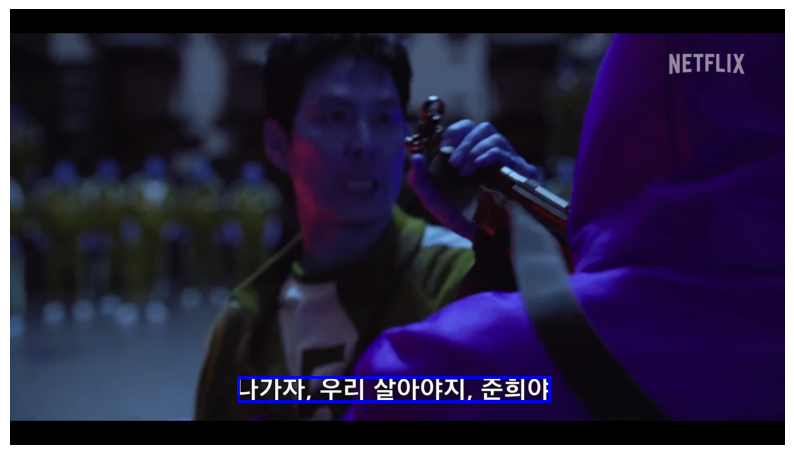

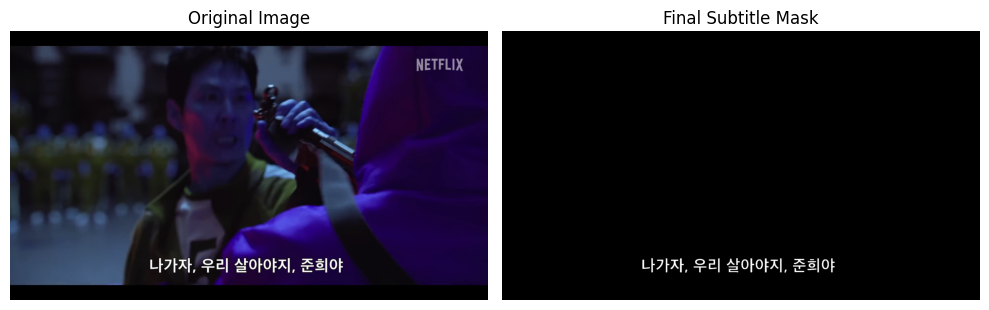

In [45]:
def get_final_bounding_box(boxes, crop_area):
    x_min = min(box['x'] for box in boxes)
    y_min = min(box['y'] for box in boxes)
    x_max = max(box['x'] + box['w'] for box in boxes)
    y_max = max(box['y'] + box['h'] for box in boxes)

    original_x_min = crop_area['left'] + x_min
    original_y_min = crop_area['top'] + y_min
    original_x_max = crop_area['left'] + x_max
    original_y_max = crop_area['top'] + y_max

    cropped_final_box = {
        "x": x_min,
        "y": y_min,
        "w": x_max - x_min,
        "h": y_max - y_min,
    }

    final_box = {
        "x": original_x_min,
        "y": original_y_min,
        "w": original_x_max - original_x_min,
        "h": original_y_max - original_y_min,
    }
    return cropped_final_box, final_box

def get_final_subtitle_mask(highlighted_image, original_image, cropped_final_box, crop_area):
    x, y, w, h = cropped_final_box['x'], cropped_final_box['y'], cropped_final_box['w'], cropped_final_box['h']
    mask = np.zeros_like(highlighted_image, dtype=np.uint8)
    roi_highlighted = highlighted_image[y:y+h, x:x+w]
    white_pixels_condition = np.all(roi_highlighted == [255, 255, 255], axis=2)
    mask[y:y+h, x:x+w][white_pixels_condition] = [255, 255, 255]

    # 원본 이미지에 맞게 마스크 조정
    original_mask = np.zeros_like(original_image, dtype=np.uint8)
    original_mask[crop_area['top'] + y:crop_area['top'] + y + h, crop_area['left'] + x:crop_area['left'] + x + w] = mask[y:y+h, x:x+w]

    return original_mask

def visualize_final_mask(image, mask):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Final Subtitle Mask")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


cropped_final_bounding_box, final_bounding_box = get_final_bounding_box(mode_boxes, crop_range)
visualize_boxes(sample_original_image, [final_bounding_box])
final_subtitle_mask = get_final_subtitle_mask(sample_highlight_result['highlighted_image'], sample_original_image, cropped_final_bounding_box, crop_range)
visualize_final_mask(sample_original_image, final_subtitle_mask)

# 총정리

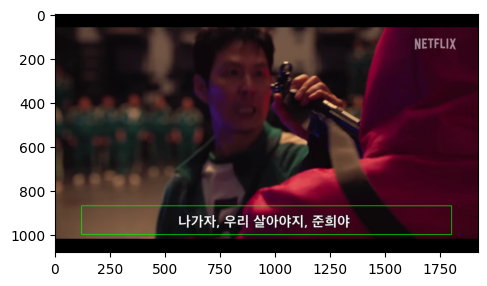

In [ ]:
video_path = './videos/Squid_game.mp4'
crop_range = {"top": 870, "bottom": 1000, "left": 120, "right": 1800}
target_pixel = (65, 945)

## target_color = get_target_color(cropped_images[0], target_pixel)
target_color = [255, 255, 255]

pixel_highlighting_tolerances = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

psm_modes = {
    "psm6": '--oem 3 --psm 6 -l kor+eng',
    "psm8": '--oem 3 --psm 8 -l kor+eng',
    "psm10": '--oem 3 --psm 10 -l kor+eng'
}
conf_thresholds = [0, 10, 50]

plt.figure(figsize=(12, 5))
original_frame_with_crop_rect = frames[1500].copy()
cv2.rectangle(original_frame_with_crop_rect, 
                (crop_range["left"], crop_range["top"]), 
                (crop_range["right"], crop_range["bottom"]), 
                (0, 255, 0), 2)
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_frame_with_crop_rect, cv2.COLOR_BGR2RGB))

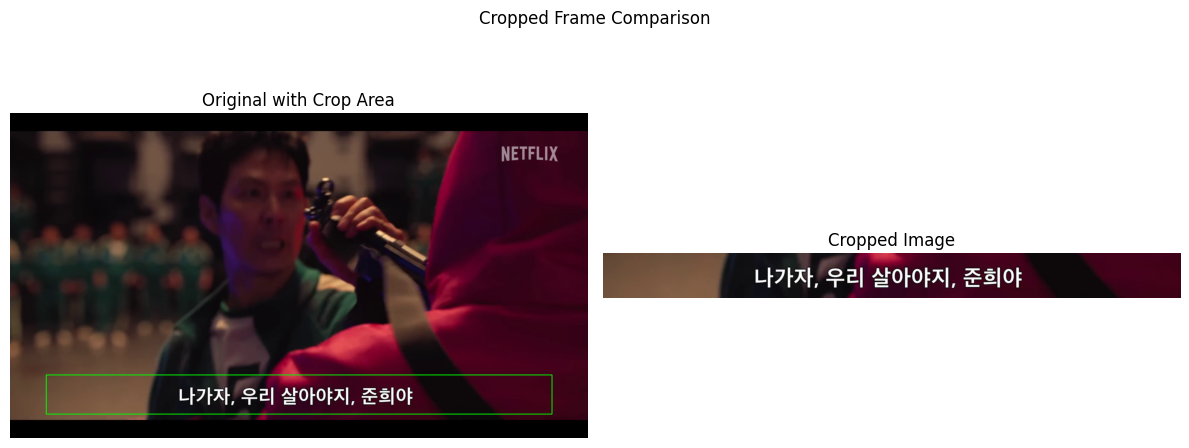

총 722개의 박스가 발견되었습니다.


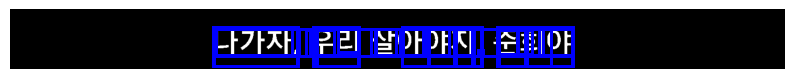

총 722개의 박스가 발견되었습니다.


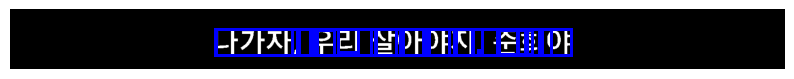

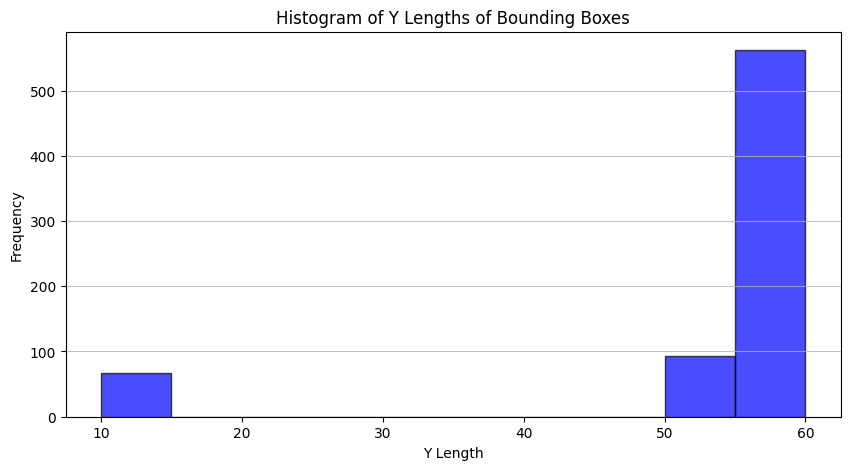

최빈 y 길이 범위: (np.int64(55), np.int64(60)), 개수: 562
총 562개의 박스가 발견되었습니다.


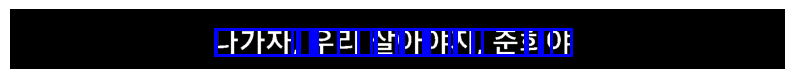

총 1개의 박스가 발견되었습니다.


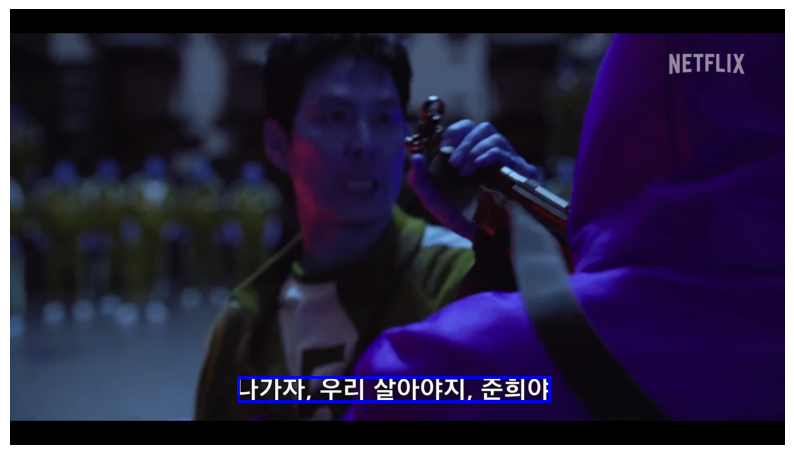

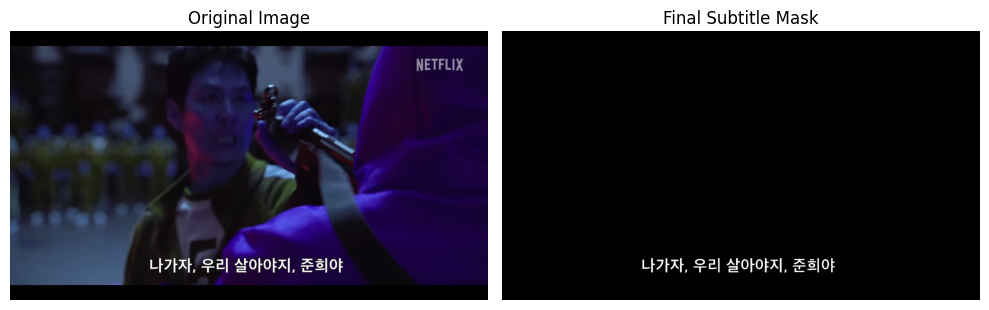

In [61]:
sample_image = frames[1500]

def extract_subtitle_pixel_from_image(original_image, target_color, crop_area):
    cropped_image = crop_image(original_image, crop_area)
    display_cropped_frame(original_image, crop_area, title="Cropped Frame Comparison")

    highlight_results = highlight_subtitle_area_with_multi_tolerances(cropped_image, target_color, pixel_highlighting_tolerances)
    highlighted_image = highlight_results[9]['highlighted_image']
    all_boxes = find_boundingbox_from_highlighted_results(highlight_results, psm_modes, conf_thresholds)
    visualize_boxes(highlighted_image, all_boxes)
    
    trimmed_boxes = boxes_trimming(highlighted_image, all_boxes, target_color, box_trimming_tolerance=30)
    visualize_boxes(highlighted_image, trimmed_boxes)

    if( len(trimmed_boxes) < 50):
        print("No boxes found after trimming. Exiting.")
        return None, None
    
    histogram_ylength(trimmed_boxes)
    mode_boxes = find_ylength_mode_boxes(trimmed_boxes)
    visualize_boxes(highlighted_image, mode_boxes)

    cropped_bounding_box, final_bounding_box = get_final_bounding_box(mode_boxes, crop_range)
    visualize_boxes(original_image, [final_bounding_box])

    final_subtitle_mask = get_final_subtitle_mask(highlighted_image, original_image, cropped_bounding_box, crop_area)
    visualize_final_mask(original_image, final_subtitle_mask)

    return final_bounding_box, final_subtitle_mask

bounding_box, subtitle_mask = extract_subtitle_pixel_from_image(sample_image, target_color, crop_area=crop_range)

Processing frame 0/172
최빈 y 길이 범위: (np.int64(54), np.int64(59)), 개수: 385


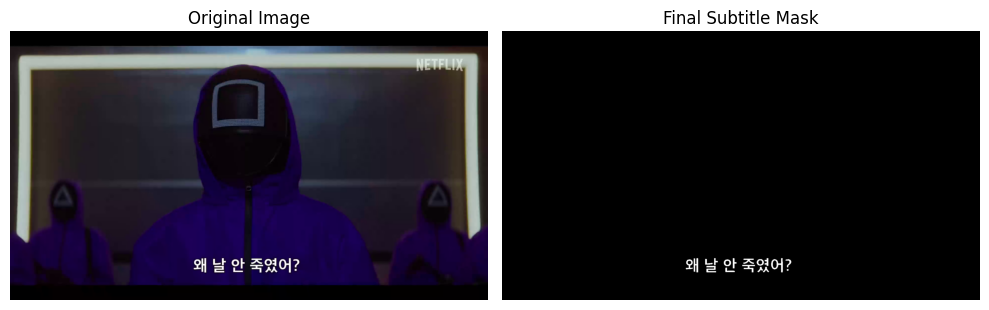

Frame 0: Bounding Box: {'x': 738, 'y': 912, 'w': 424, 'h': 57}, Subtitle Mask shape: (1080, 1920, 3)
최빈 y 길이 범위: (np.int64(54), np.int64(59)), 개수: 385


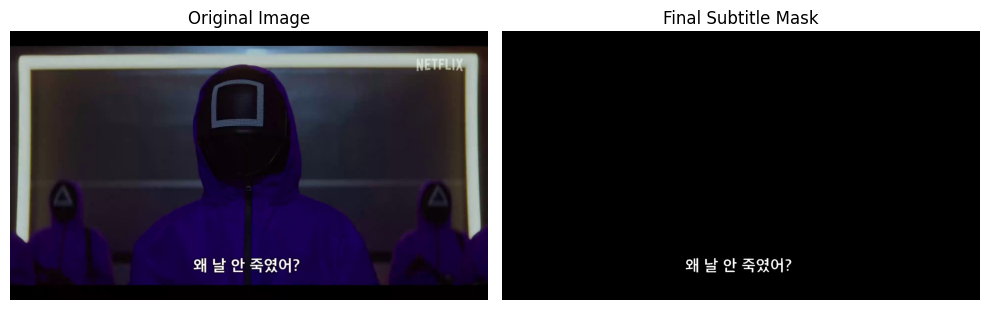

Frame 1: Bounding Box: {'x': 738, 'y': 912, 'w': 424, 'h': 57}, Subtitle Mask shape: (1080, 1920, 3)
최빈 y 길이 범위: (np.int64(56), np.int64(61)), 개수: 295


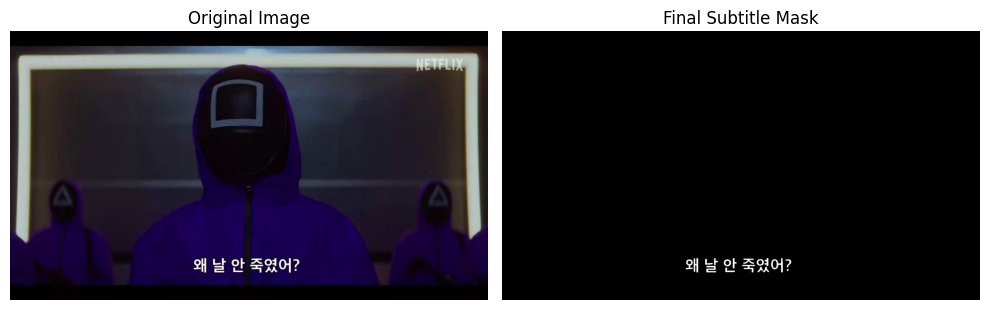

Frame 2: Bounding Box: {'x': 738, 'y': 912, 'w': 424, 'h': 57}, Subtitle Mask shape: (1080, 1920, 3)
최빈 y 길이 범위: (np.int64(56), np.int64(61)), 개수: 263


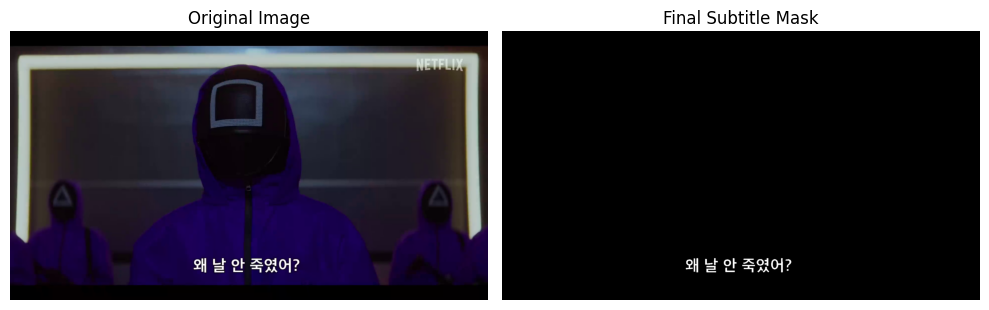

Frame 3: Bounding Box: {'x': 738, 'y': 912, 'w': 424, 'h': 57}, Subtitle Mask shape: (1080, 1920, 3)
최빈 y 길이 범위: (np.int64(56), np.int64(61)), 개수: 304


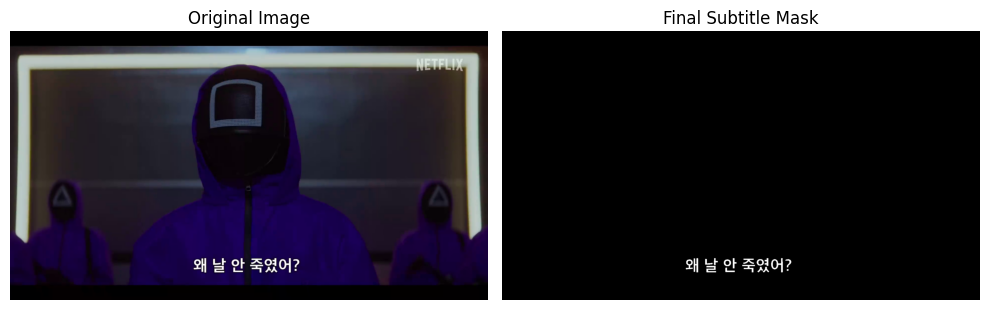

Frame 4: Bounding Box: {'x': 738, 'y': 912, 'w': 424, 'h': 57}, Subtitle Mask shape: (1080, 1920, 3)
최빈 y 길이 범위: (np.int64(56), np.int64(61)), 개수: 329


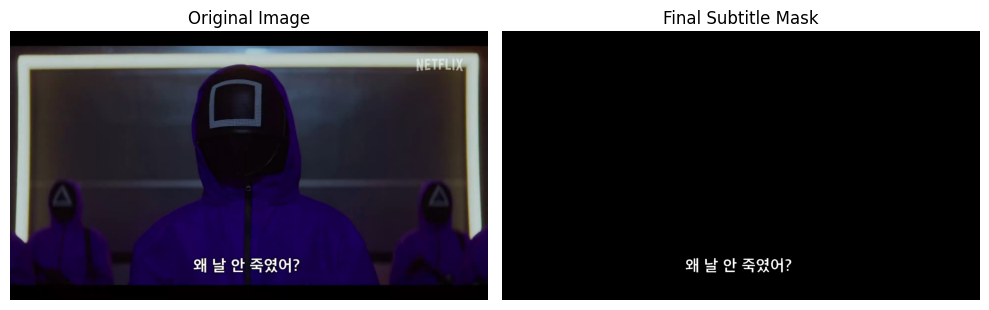

Frame 5: Bounding Box: {'x': 738, 'y': 912, 'w': 424, 'h': 58}, Subtitle Mask shape: (1080, 1920, 3)
최빈 y 길이 범위: (np.int64(56), np.int64(61)), 개수: 351


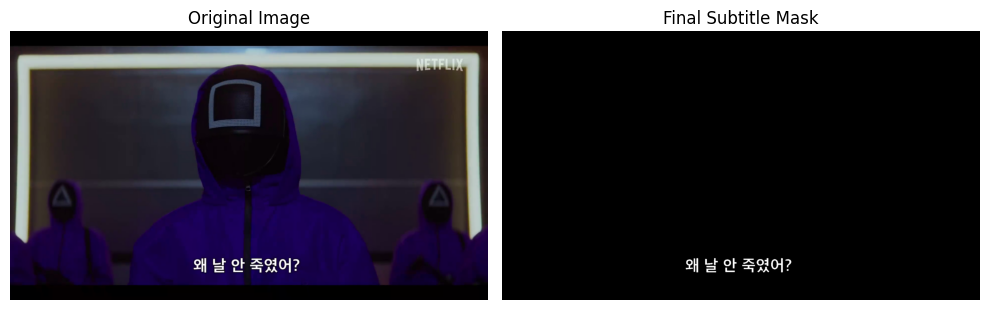

Frame 6: Bounding Box: {'x': 738, 'y': 912, 'w': 424, 'h': 58}, Subtitle Mask shape: (1080, 1920, 3)
최빈 y 길이 범위: (np.int64(56), np.int64(61)), 개수: 338


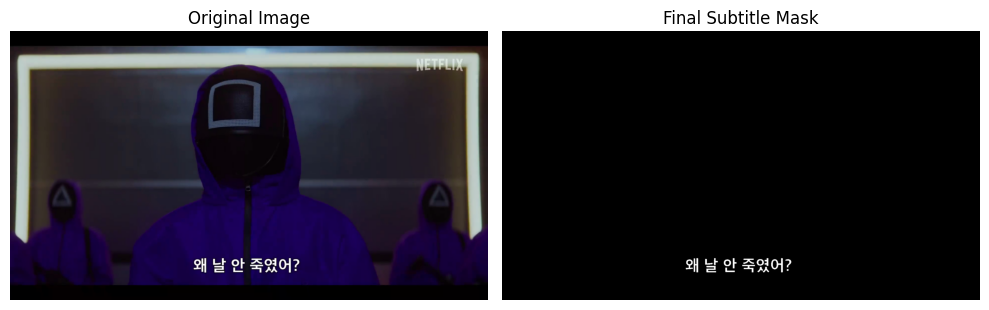

Frame 7: Bounding Box: {'x': 738, 'y': 912, 'w': 424, 'h': 58}, Subtitle Mask shape: (1080, 1920, 3)
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found after trimming. Exiting.
No boxes found afte

In [ ]:
sample_image = frames[1500]
video_path = './videos/Squid_game - Trim.mp4'


def extract_subtitle_pixel_from_image(original_image, target_color, crop_area):
    cropped_image = crop_image(original_image, crop_area)

    highlight_results = highlight_subtitle_area_with_multi_tolerances(cropped_image, target_color, pixel_highlighting_tolerances)
    highlighted_image = highlight_results[9]['highlighted_image']
    all_boxes = find_boundingbox_from_highlighted_results(highlight_results, psm_modes, conf_thresholds)
    
    trimmed_boxes = boxes_trimming(highlighted_image, all_boxes, target_color, box_trimming_tolerance=30)

    if( len(trimmed_boxes) < 50):
        print("No boxes found after trimming. Exiting.")
        return None, None
    
    mode_boxes = find_ylength_mode_boxes(trimmed_boxes)

    cropped_bounding_box, final_bounding_box = get_final_bounding_box(mode_boxes, crop_range)

    final_subtitle_mask = get_final_subtitle_mask(highlighted_image, original_image, cropped_bounding_box, crop_area)
    visualize_final_mask(original_image, final_subtitle_mask)

    return final_bounding_box, final_subtitle_mask

def extract_subtitle_pixel_from_video(video_path, target_color, crop_area):
    frames = load_video(video_path)
    bounding_boxes = []
    subtitle_masks = []
    for i, frame in enumerate(frames):
        if i % 100 == 0:
            print(f"Processing frame {i}/{len(frames)}")
        bounding_box, subtitle_mask = extract_subtitle_pixel_from_image(frame, target_color, crop_area)
        bounding_boxes.append(bounding_box)
        subtitle_masks.append(subtitle_mask)
        if bounding_box is not None and subtitle_mask is not None:
            print(f"Frame {i}: Bounding Box: {bounding_box}, Subtitle Mask shape: {subtitle_mask.shape}")
    print("Video processing complete.")
    return bounding_boxes, subtitle_masks

extract_subtitle_pixel_from_video(video_path, target_color, crop_area=crop_range)